1) Kütüphaneler başarıyla yüklendi.
2) Veri seti başarıyla okundu. Boyut: (210, 8)
3) Veri ön işleme ve ölçeklendirme adımları tamamlandı.
4) PCA ile verinin boyutları grafik için 2'ye düşürüldü.
5) Tüm modeller (K-Means, Hiyerarşik, DBSCAN, GMM) başarıyla eğitildi.
--------------------------------------------------
K-means Silhouette Skoru: 0.4007
Hiyerarşik Silhouette Skoru: 0.3926
GMM Silhouette Skoru: 0.3625
--------------------------------------------------


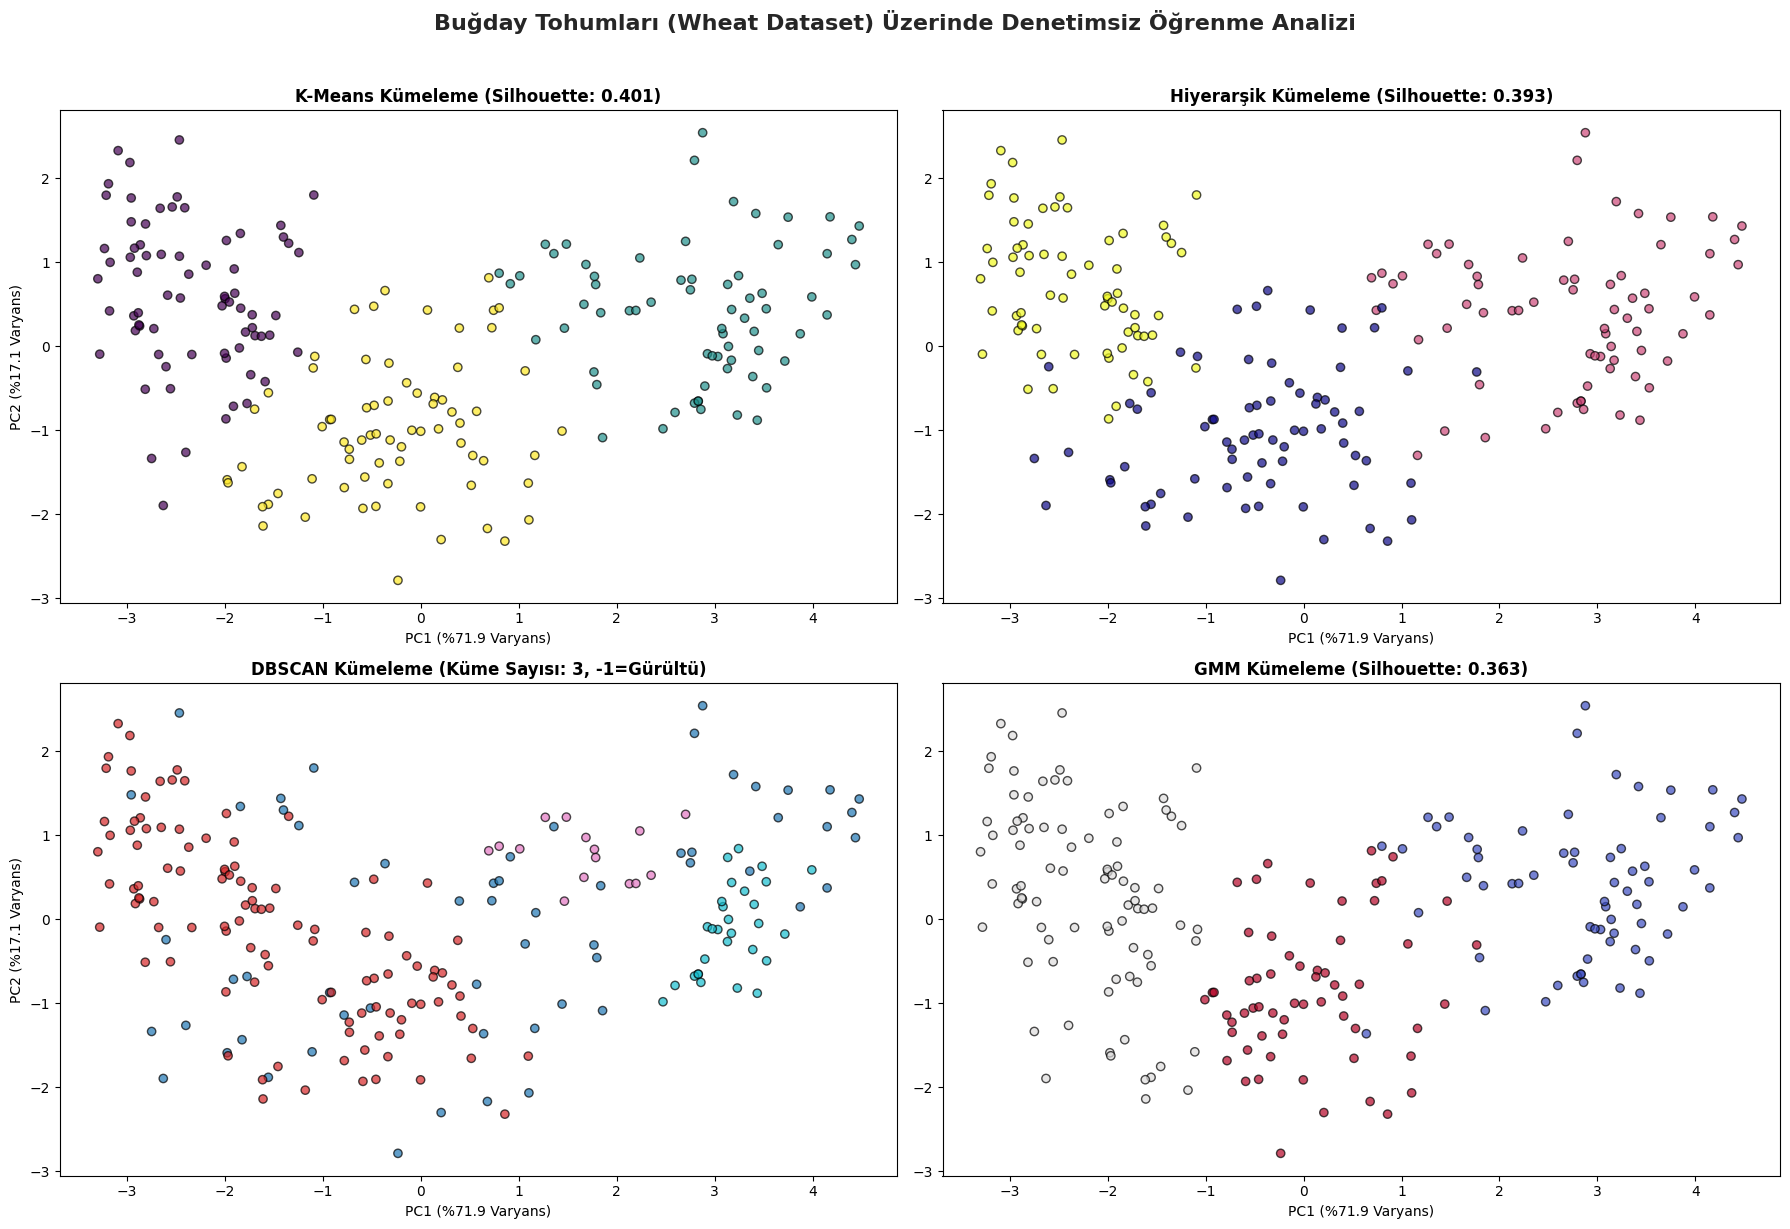

In [2]:
# ==============================================================================
# ADIM 1: TÜM KÜTÜPHANELERİN YÜKLENMESİ
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("1) Kütüphaneler başarıyla yüklendi.")

# ==============================================================================
# ADIM 2: VERİ YÜKLEME VE ÖN İŞLEME
# ==============================================================================
try:
    df = pd.read_csv('wheat.csv')
    print(f"2) Veri seti başarıyla okundu. Boyut: {df.shape}")
except FileNotFoundError:
    print("HATA: 'wheat.csv' dosyası bulunamadı! Lütfen sol taraftaki panelden dosyayı Colab'a yükleyin.")

# Denetimsiz öğrenme için hedef değişken olan 'category' sütununu gizliyoruz
X = df.drop(columns=['category'])

# Eksik değerleri doldurma ve StandardScaler ile ölçeklendirme
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X_imputed)
x_scaled = pd.DataFrame(x_scaled, columns=X_imputed.columns)
print("3) Veri ön işleme ve ölçeklendirme adımları tamamlandı.")

# ==============================================================================
# ADIM 3: PCA BOYUT AZALTMA (Görselleştirme İçin)
# ==============================================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)
var_1 = pca.explained_variance_ratio_[0] * 100
var_2 = pca.explained_variance_ratio_[1] * 100
print("4) PCA ile verinin boyutları grafik için 2'ye düşürüldü.")

# ==============================================================================
# ADIM 4: MODELLERİN EĞİTİLMESİ
# ==============================================================================
optimal_k = 3 # Doğadaki 3 farklı buğday türü için standart değerimiz

# A) K-Means
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

# B) Hiyerarşik Kümeleme
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(x_scaled)

# C) DBSCAN (Buğday verisi için en kararlı eps=0.8 değeridir)
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# D) Gaussian Mixture Model (Hatalı parametre 'max_iter' olarak düzeltildi)
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', max_iter=200, random_state=42)
gmm_labels = gmm.fit_predict(x_scaled)

print("5) Tüm modeller (K-Means, Hiyerarşik, DBSCAN, GMM) başarıyla eğitildi.")
print("-" * 50)
print(f'K-means Silhouette Skoru: {silhouette_score(x_scaled, kmeans_labels):.4f}')
print(f'Hiyerarşik Silhouette Skoru: {silhouette_score(x_scaled, agg_labels):.4f}')
print(f'GMM Silhouette Skoru: {silhouette_score(x_scaled, gmm_labels):.4f}')
print("-" * 50)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.set_style('whitegrid')

# K-Means Grafiği (Sol Üst)
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', alpha=0.7)
axes[0, 0].set_title(f'K-Means Kümeleme (Silhouette: {silhouette_score(x_scaled, kmeans_labels):.3f})', fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 (%{var_1:.1f} Varyans)')
axes[0, 0].set_ylabel(f'PC2 (%{var_2:.1f} Varyans)')

# Hiyerarşik Kümeleme Grafiği (Sağ Üst)
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma', edgecolors='k', alpha=0.7)
axes[0, 1].set_title(f'Hiyerarşik Kümeleme (Silhouette: {silhouette_score(x_scaled, agg_labels):.3f})', fontweight='bold')
axes[0, 1].set_xlabel(f'PC1 (%{var_1:.1f} Varyans)')

# DBSCAN Grafiği (Sol Alt)
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', edgecolors='k', alpha=0.7)
axes[1, 0].set_title(f'DBSCAN Kümeleme (Küme Sayısı: {n_clusters_db}, -1=Gürültü)', fontweight='bold')
axes[1, 0].set_xlabel(f'PC1 (%{var_1:.1f} Varyans)')
axes[1, 0].set_ylabel(f'PC2 (%{var_2:.1f} Varyans)')

# GMM Grafiği (Sağ Alt)
axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm', edgecolors='k', alpha=0.7)
axes[1, 1].set_title(f'GMM Kümeleme (Silhouette: {silhouette_score(x_scaled, gmm_labels):.3f})', fontweight='bold')
axes[1, 1].set_xlabel(f'PC1 (%{var_1:.1f} Varyans)')

plt.suptitle('Buğday Tohumları (Wheat Dataset) Üzerinde Denetimsiz Öğrenme Analizi', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()